In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.notebook import tqdm

In [2]:
CLEAN_ROOT = Path('../../data/cmhc-rental-clean')
REF_ROOT   = Path('../../data/reference')
REF_ROOT.mkdir(parents=True, exist_ok=True)

# ── CPI, all-items, 2002=100 (Statistics Canada) ─────────────────────────
CPI_YEARS  = list(range(1990, 2026))
CPI_VALUES = [
    78.7,  82.4,  83.2,  84.7,  84.7,  86.8,  88.2,  89.8,  90.6,  92.4,
    95.1,  98.0, 100.0, 102.7, 104.6, 106.9, 108.8, 110.8, 113.3, 113.7,
   116.5, 120.1, 121.8, 123.0, 125.9, 127.4, 129.7, 131.9, 135.0, 137.5,
   138.4, 143.2, 152.9, 158.7, 162.5, 165.6,
]

# ── Ontario rent-control guideline (annual max % increase) ───────────────
# No entry for 1990 — that is the base year (no prior-year to compound from).
RENT_CONTROL = {
    1991: 5.4, 1992: 6.0, 1993: 4.9, 1994: 3.2, 1995: 2.9,
    1996: 2.8, 1997: 2.8, 1998: 3.0, 1999: 3.0, 2000: 2.6,
    2001: 2.9, 2002: 3.9, 2003: 2.9, 2004: 2.9, 2005: 1.5,
    2006: 2.1, 2007: 2.6, 2008: 1.4, 2009: 1.8, 2010: 2.1,
    2011: 0.7, 2012: 3.1, 2013: 2.5, 2014: 0.8, 2015: 1.6,
    2016: 2.0, 2017: 1.5, 2018: 1.8, 2019: 1.8, 2020: 2.2,
    2021: 0.0, 2022: 1.2, 2023: 2.5, 2024: 2.5, 2025: 2.5,
}

# ── Ontario population, Q1 estimates (Statistics Canada) ─────────────────
POP_Q1 = {
    1990: 10_189_985, 1991: 10_355_101, 1992: 10_488_022, 1993: 10_629_994,
    1994: 10_744_762, 1995: 10_875_308, 1996: 11_009_307, 1997: 11_146_270,
    1998: 11_292_059, 1999: 11_419_589, 2000: 11_576_994, 2001: 11_771_945,
    2002: 11_979_906, 2003: 12_155_691, 2004: 12_303_516, 2005: 12_444_755,
    2006: 12_587_149, 2007: 12_703_327, 2008: 12_814_686, 2009: 12_932_742,
    2010: 13_059_426, 2011: 13_199_081, 2012: 13_325_337, 2013: 13_446_276,
    2014: 13_563_311, 2015: 13_657_423, 2016: 13_774_364, 2017: 13_975_516,
    2018: 14_199_811, 2019: 14_449_986, 2020: 14_718_155, 2021: 14_761_811,
    2022: 14_947_417, 2023: 15_305_369, 2024: 15_823_956, 2025: 16_191_372,
}

# ── Analysis periods (seven-year chunks) ─────────────────────────────────
PERIODS = [
    (1990, 1997),
    (1997, 2004),
    (2004, 2011),
    (2011, 2018),
    (2018, 2025),
]

BASE_YEAR  = 1990
INDEX_BASE = 500

# ── Chart style (reference palette) ──────────────────────────────────────
# Categorical slots in fixed CVD-safe order:
C1 = '#2a78d6'  # blue   — rent
C2 = '#1baf7a'  # aqua   — CPI
C3 = '#eda100'  # yellow — rent control
C4 = '#008300'  # green  — population
# C5 reserved for income when data is available

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

## Section 1 — Reference Data

Persist CPI, rent-control guideline, and Ontario population series to
`data/reference/` so other notebooks can load them without re-entering raw values.
Population uses Q1 estimates; CPI is annual all-items; rent control is the Ontario
annual guideline maximum.

In [3]:
pd.DataFrame({'Year': CPI_YEARS, 'CPI': CPI_VALUES}).to_csv(
    REF_ROOT / 'cpi_canada.csv', index=False)

pd.DataFrame(sorted(RENT_CONTROL.items()), columns=['Year', 'Guideline_Pct']).to_csv(
    REF_ROOT / 'rent_control_ontario.csv', index=False)

pd.DataFrame(sorted(POP_Q1.items()), columns=['Year', 'Population']).to_csv(
    REF_ROOT / 'population_ontario_q1.csv', index=False)

for f in sorted(REF_ROOT.glob('*.csv')):
    print(f.name)

cpi_canada.csv
population_ontario_q1.csv
rent_control_ontario.csv


## Section 2 — Rent vs. Benchmarks (Indexed to 500, base 1990)

Rescaling everything to 500 in 1990 lets us compare growth rates directly across
series with very different units (dollars, index points, people).

**Rent control** is compounded annually from 1990 using the guideline rate — it
shows what rent *would* be today if it had risen exactly at the allowed maximum
every year since 1990.  Note that rent control only applies to units built before
November 2018, and vacant-unit turnover can reset rents to market.

*Slot C5 (income) is reserved — add when data is available.*

In [4]:
ontario = pd.read_csv(
    CLEAN_ROOT / 'can-pr-primary/primary-summary/ontario.csv'
).set_index('Year')

# Rent: direct ratio to base year
rent_idx = INDEX_BASE * ontario['Average Rent'] / ontario.loc[BASE_YEAR, 'Average Rent']

# CPI: direct ratio to base year
cpi_s    = pd.Series(CPI_VALUES, index=CPI_YEARS)
cpi_idx  = INDEX_BASE * cpi_s / cpi_s[BASE_YEAR]

# Rent control: cumulative compound from 1990
rc_idx = pd.Series(index=range(BASE_YEAR, 2026), dtype=float)
rc_idx[BASE_YEAR] = INDEX_BASE
for yr in range(BASE_YEAR + 1, 2026):
    rc_idx[yr] = rc_idx[yr - 1] * (1 + RENT_CONTROL.get(yr, 0.0) / 100)

# Population: direct ratio to base year
pop_s   = pd.Series(POP_Q1).sort_index()
pop_idx = INDEX_BASE * pop_s / pop_s[BASE_YEAR]

benchmark = pd.DataFrame({
    'Rent (Ontario)':  rent_idx,
    'CPI':             cpi_idx,
    'Rent Control':    rc_idx,
    'Population (ON)': pop_idx,
}).loc[1990:2025]

benchmark.tail(3)

,Rent (Ontario),CPI,Rent Control,Population (ON)
2023,1396.701389,1008.259212,1125.617036,751.000566
2024,1446.180556,1032.401525,1153.757461,776.446482
2025,1501.736111,1052.096569,1182.601398,794.474771


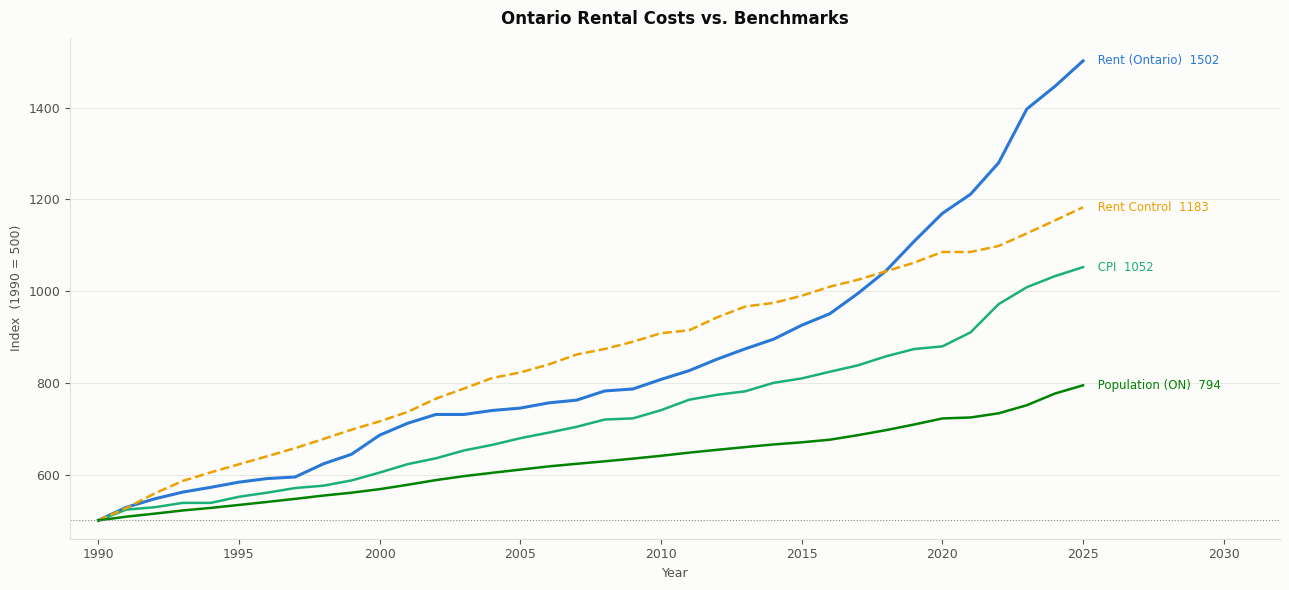

In [5]:
SERIES_STYLE = {
    'Rent (Ontario)':  dict(color=C1, linestyle='solid',  linewidth=2.2),
    'CPI':             dict(color=C2, linestyle='solid',  linewidth=1.8),
    'Rent Control':    dict(color=C3, linestyle='dashed', linewidth=1.8),
    'Population (ON)': dict(color=C4, linestyle='solid',  linewidth=1.8),
}

fig, ax = plt.subplots(figsize=(13, 6))

for label, style in SERIES_STYLE.items():
    ax.plot(benchmark.index, benchmark[label], **style, label=label)

# Direct labels at 2025 — avoids a legend box
for label, style in SERIES_STYLE.items():
    val = benchmark.loc[2025, label]
    ax.text(2025.4, val, f' {label}  {val:.0f}',
            color=style['color'], va='center', fontsize=8.5)

ax.axhline(INDEX_BASE, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlim(1989, 2032)
ax.set_ylim(bottom=460)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Index  (1990 = 500)', fontsize=9)
ax.set_title('Ontario Rental Costs vs. Benchmarks', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='y')
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Section 3 — Supply and Rent: Ontario Level

Each dot is one seven-year period.  If supply growth suppressed rent, we would
expect a negative slope — more units built → smaller rent increase.  Instead,
the post-2011 periods show that the largest supply additions coincided with the
largest rent increases, suggesting demand shocks (immigration, household formation)
consistently outpaced supply.

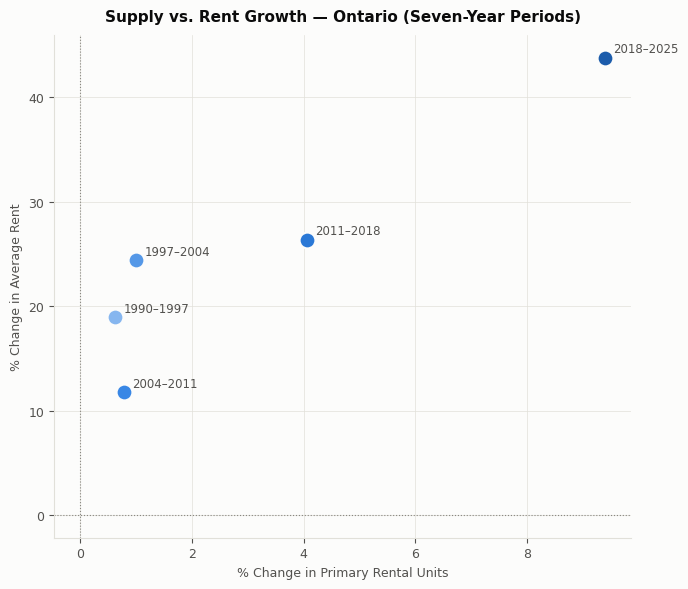

,Period,pct_units,pct_rent
0,1990–1997,0.6,18.9
1,1997–2004,1.0,24.4
2,2004–2011,0.8,11.7
3,2011–2018,4.1,26.4
4,2018–2025,9.4,43.8


In [6]:
period_rows = []
for start_yr, end_yr in PERIODS:
    r_start = ontario.loc[start_yr, 'Average Rent']
    r_end   = ontario.loc[end_yr,   'Average Rent']
    u_start = ontario.loc[start_yr, 'Units']
    u_end   = ontario.loc[end_yr,   'Units']
    period_rows.append({
        'Period':      f'{start_yr}\u2013{end_yr}',
        'pct_rent':    (r_end - r_start) / r_start * 100,
        'pct_units':   (u_end - u_start) / u_start * 100,
        'units_start': u_start,
    })

period_df = pd.DataFrame(period_rows)

# Sequential blue ramp: earlier period = lighter
PERIOD_COLORS = ['#86b6ef', '#5598e7', '#3987e5', '#2a78d6', '#1c5cab']

fig, ax = plt.subplots(figsize=(7, 6))

for i, row in period_df.iterrows():
    ax.scatter(row['pct_units'], row['pct_rent'],
               color=PERIOD_COLORS[i], s=130, zorder=5,
               edgecolors=SURFACE, linewidths=1.5)
    ax.annotate(row['Period'],
                (row['pct_units'], row['pct_rent']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8.5, color=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('% Change in Primary Rental Units', fontsize=9)
ax.set_ylabel('% Change in Average Rent', fontsize=9)
ax.set_title('Supply vs. Rent Growth \u2014 Ontario (Seven-Year Periods)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

period_df[['Period', 'pct_units', 'pct_rent']].round(1)

## Section 4 — Supply and Rent: City Level (Small Multiples)

Each panel is one seven-year period; each dot is an Ontario CSD city.  Dot size
scales with the number of primary rental units at the start of the period
(larger city = bigger dot).  Cities without data for both endpoints of a period
are omitted from that panel.

The dashed line is an OLS fit.  If supply suppressed rents we would expect a
negative slope (more units built → smaller rent increase).

In [7]:
CITY_DIR = CLEAN_ROOT / 'on-csd-primary/primary-summary'

city_data = {}
for fp in tqdm(sorted(CITY_DIR.glob('*.csv'))):
    df = pd.read_csv(fp).set_index('Year')
    city_data[fp.stem] = df


def period_city_df(start_yr: int, end_yr: int) -> pd.DataFrame:
    """Return a df with one row per city that has data at both endpoints."""
    rows = []
    for city, df in city_data.items():
        try:
            r0 = df.loc[start_yr, 'Average Rent']
            r1 = df.loc[end_yr,   'Average Rent']
            u0 = df.loc[start_yr, 'Units']
            u1 = df.loc[end_yr,   'Units']
        except KeyError:
            continue
        if any(pd.isna(v) for v in (r0, r1, u0, u1)) or u0 == 0:
            continue
        rows.append({
            'city':        city,
            'pct_rent':    (r1 - r0) / r0  * 100,
            'pct_units':   (u1 - u0) / u0  * 100,
            'units_start': u0,
        })
    return pd.DataFrame(rows)


period_city_dfs = {f'{s}\u2013{e}': period_city_df(s, e) for s, e in PERIODS}

for label, df in period_city_dfs.items():
    print(f'{label}: {len(df)} cities')

  0%|          | 0/34 [00:00<?, ?it/s]

1990–1997: 24 cities
1997–2004: 25 cities
2004–2011: 32 cities
2011–2018: 32 cities
2018–2025: 32 cities


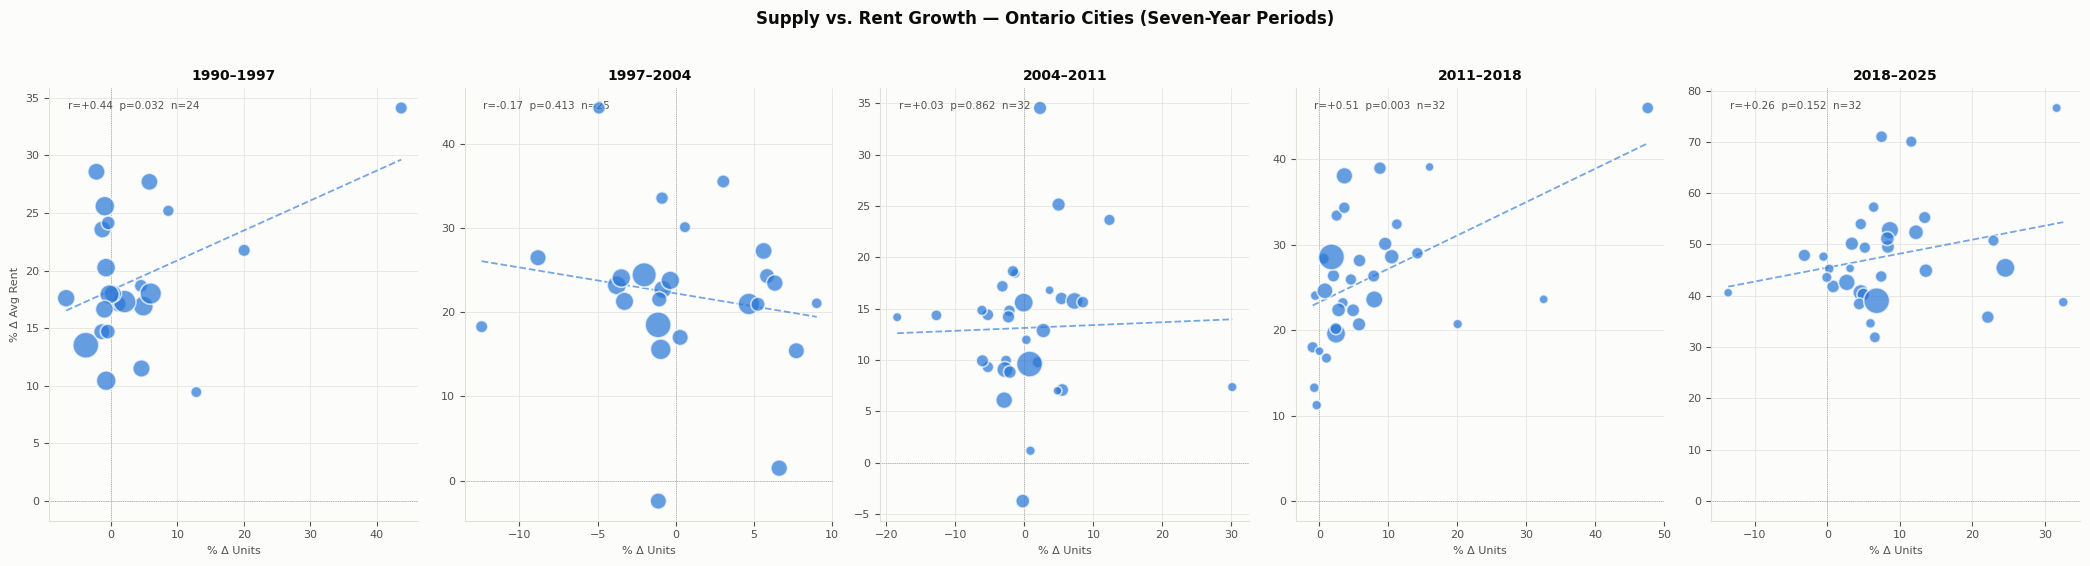

In [8]:
MIN_S, MAX_S = 25, 350

fig, axes = plt.subplots(1, 5, figsize=(21, 5.5))
fig.suptitle('Supply vs. Rent Growth \u2014 Ontario Cities (Seven-Year Periods)',
             fontsize=12, fontweight='bold', color=INK, y=1.02)

for ax, (label, df) in zip(axes, period_city_dfs.items()):
    ax.set_title(label, fontsize=10, fontweight='bold', color=INK)

    if df.empty or len(df) < 3:
        ax.text(0.5, 0.5, 'Insufficient data',
                ha='center', va='center', transform=ax.transAxes,
                color=MUTED, fontsize=9)
        continue

    # Bubble size: sqrt-scaled so area ~ units
    sz = MIN_S + (np.sqrt(df['units_start']) / np.sqrt(df['units_start'].max())) * (MAX_S - MIN_S)

    ax.scatter(df['pct_units'], df['pct_rent'],
               s=sz, color=C1, alpha=0.72,
               edgecolors=SURFACE, linewidths=1.2, zorder=5)

    # OLS fit
    slope, intercept, r, p, _ = stats.linregress(df['pct_units'], df['pct_rent'])
    xfit = np.linspace(df['pct_units'].min(), df['pct_units'].max(), 100)
    ax.plot(xfit, slope * xfit + intercept,
            color=C1, linewidth=1.3, linestyle='--', alpha=0.65)

    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.text(0.05, 0.97,
            f'r={r:+.2f}  {p_str}  n={len(df)}',
            transform=ax.transAxes, va='top',
            fontsize=7.5, color=INK2)

    ax.axhline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.axvline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.set_xlabel('% \u0394 Units', fontsize=8, color=INK2)
    if ax is axes[0]:
        ax.set_ylabel('% \u0394 Avg Rent', fontsize=8, color=INK2)
    ax.grid()
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [9]:
# Pool all city-period observations for an overall test
pooled = pd.concat(
    [df.assign(period=label) for label, df in period_city_dfs.items()],
    ignore_index=True,
)

r_all, p_all = stats.pearsonr(pooled['pct_units'], pooled['pct_rent'])
print(f'Pooled (all cities x periods)  r = {r_all:+.3f}  p = {p_all:.4f}  n = {len(pooled)}')
print()

# Per-period breakdown
rows = []
for label, df in period_city_dfs.items():
    if len(df) < 3:
        rows.append({'Period': label, 'r': None, 'p': None, 'n': len(df), 'note': 'too few cities'})
        continue
    r, p = stats.pearsonr(df['pct_units'], df['pct_rent'])
    rows.append({'Period': label, 'r': round(r, 3), 'p': round(p, 4), 'n': len(df), 'note': ''})

stats_df = pd.DataFrame(rows).set_index('Period')
stats_df

Pooled (all cities x periods)  r = +0.366  p = 0.0000  n = 145



,r,p,n,note
Period,,,,
1990–1997,0.438,0.0324,24,
1997–2004,-0.171,0.4132,25,
2004–2011,0.032,0.8621,32,
2011–2018,0.511,0.0028,32,
2018–2025,0.259,0.1520,32,
